# Reconstruction Notebook

This notebook can be used to recreate the plots and performance files for the 3 distributions we have made.

To run a test, you can change the number of epochs, learning rate, alpha_prior (in case of dirichlet), hidden dimensions and batch size.

In case the model for the test already exists, the program will load that model and make plots based on it. To train a new model from scratch, and generate new plots,
you need to re-locate the already existing model, delete it and run the script again.

## Gaussian VAE implementation

In [2]:
"""
Implementation of a Gaussian Variational AutoEncoder for a MNIST dataset
Encoder:
    Linear(784 - 500)
    BatchNorm()
    ReLU()
    Linear(400 - 50)
    Softplus()

The Latent Variable Z will have d=50 or d=10 dimensions 

Decoder:
    Linear(50 - 500)
    BatchNorm()
    ReLU()
    Linear(500 - 784)
"""

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Uniform
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import math
import matplotlib
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(44)
NUM_EPOCHS = 50
# This is the encoder we use, it consists of a single hidden layer with ReLU activations
class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.BatchNorm1d(hidden_dims),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(hidden_dims, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dims, latent_dim)

    def forward(self, x):
        h = self.net(x)

        # Bottleneck
        z_mu = self.fc_mu(h)
        z_logvar = self.fc_logvar(h)
        
        return z_mu, z_logvar
# This is the decoder we use, it consists of a Linear Layer, BatchNorm and ReLU activations and lastly a Linear layer to output the logits
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims), 
            nn.BatchNorm1d(hidden_dims), 
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim)
        )

    def forward(self, z):
        logits = self.net(z)

        # return logits (use BCEWithLogitsLoss)
        return logits

#This is the gaussian VAE class that combines the encoder and decoder with the gaussian reparameterization sampler
class GVAE(nn.Module):
    def __init__(self, input_dim, enc_hidden_dims, dec_hidden_dims, latent_dim):
        """
        input_dim: flattened input size (e.g. 28*28)
        enc_hidden_dims:  encoder hidden sizes
        dec_hidden_dims:  decoder hidden sizes
        latent_dim: K
        """
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = MLPEncoder(input_dim, enc_hidden_dims, latent_dim)
        self.decoder = Decoder(latent_dim, dec_hidden_dims, input_dim)

    def sampling(self, z_mu, z_logvar):
        """
        reparameterization trick to sample
        """
        std = torch.exp(0.5 * z_logvar)
        eps = torch.randn_like(std)
        z = z_mu + eps * std
        
        return z
    
    def forward(self, x):
        """
        x: flattened input (batch, input_dim) with values in [0,1] for Bernoulli decoding
        returns: reconstruction logits, z_mu, z_logvar, z
        """

        # Encoder step to get the posterior parameters
        z_mu, z_logvar = self.encoder(x)  # (batch, K)

        # Sample 
        z = self.sampling(z_mu, z_logvar)  # z in simplex

        # Decoder step
        logits = self.decoder(z)  # (batch, input_dim)
        
        return logits, z_mu, z_logvar, z

#GVAE ELBO loss function
def gvae_elbo_loss(model, x):
    """
    Compute negative ELBO (loss to minimize) for Bernoulli decoder.
    x: (batch, input_dim) values in {0,1} or [0,1]
    returns loss (scalar), recon_loss (scalar), kl (scalar), z (tensor)
    """
    logits, z_mu, z_logvar, z = model(x)

    # Reconstruction: bernoulli likelihood -> BCEWithLogits
    bce = F.binary_cross_entropy_with_logits(logits, x, reduction='none')
    recon_per_sample = bce.sum(dim=1)  # per example reconstruction negative log-likelihood
    
    # Compute the mean for the batch
    recon_loss = recon_per_sample.mean()

    # KL
    z_sigma = torch.exp(0.5 * z_logvar)
    kld_loss = -0.5 * torch.sum(1 + torch.log(z_sigma**2) - z_mu**2 - z_sigma**2, dim=1)
    kl = kld_loss.mean()  # mean reduction over batch

    # ELBO
    loss = recon_loss + kl
    return loss, recon_loss, kl, z

# Training loop for GVAE
def train_loop(model, optimizer, train_loader, device):
        
        tot_loss = 0.0
        tot_recon = 0.0
        tot_kl = 0.0
        n_samples = 0
        model.train()

        for x, _ in train_loader:
            x = x.to(device)

            #Reset Gradients
            optimizer.zero_grad()

            #Foward Pass
            loss, recon, kl, _ = gvae_elbo_loss(model, x)

            #BackProp
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            tot_loss += loss.item() * batch_size
            tot_recon += recon.item() * batch_size
            tot_kl += kl.item() * batch_size
            n_samples += batch_size

        mean_loss = tot_loss / n_samples
        mean_recon = tot_recon / n_samples
        mean_kl = tot_kl / n_samples

        print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")

        return mean_loss, mean_recon, mean_kl          
# Testing loop for GVAE
def test_loop(model, test_loader, device):
    model.eval()
    tot_loss, tot_recon, tot_kl = 0.0, 0.0, 0.0
    n_samples = 0

    with torch.no_grad():
        labels = [] # For visualiation
        zs = [] # For visualization

        for x, label in test_loader:
            x = x.to(device)

            # Foward Pass
            loss, recon, kl, z = gvae_elbo_loss(model, x)

            batch_size = x.size(0)
            tot_loss += loss.item() * batch_size
            tot_recon += recon.item() * batch_size
            tot_kl += kl.item() * batch_size
            n_samples += batch_size

            labels.append(label)
            zs.append(z)

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples
    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")

    labels = torch.cat(labels, dim=0)
    zs = torch.cat(zs, dim=0)
    
    return mean_loss, mean_recon, mean_kl
# Compute log probability of Gaussian to use in Monte Carlo NLL estimation
def gaussian_log_prob(z, mu, logvar, eps=1e-8):
    """
    log N(z | mu, sigma^2) = -0.5 * [log(2*pi) + logvar + (z - mu)^2 / sigma^2]
    z: (K, B, latent_dim) or (batch, latent_dim)
    mu: (batch, latent_dim) or (1, B, latent_dim)
    logvar: (batch, latent_dim) or (1, B, latent_dim)
    Returns log probability per sample
    """
    sigma_sq = torch.exp(logvar).clamp(min=eps)
    log_p = -0.5 * (math.log(2 * math.pi) + logvar + (z - mu) ** 2 / sigma_sq)
    return log_p.sum(dim=-1)

# Monte Carlo estimate of the marginal negative log-likelihood
@torch.no_grad()
def montecarlo_nll(model, data_loader, device, K=500):
    """
    Monte Carlo (importance-weighted) estimate of the marginal log-likelihood:
        p(x) ≈ (1/K) Σ_i p(x|z_i)p(z_i)/q(z_i)
    Returns the mean NLL (nats per image) for Gaussian VAE.
    
    For Gaussian VAE:
    - q(z|x) = N(mu(x), sigma^2(x))  (posterior)
    - p(z) = N(0, I)                  (prior)
    - p(x|z) = Bernoulli (via logits from decoder)
    """
    model.eval()
    total_nll = 0.0
    n_samples = 0

    for x, _ in data_loader:
        x = x.to(device)
        B = x.size(0)

        # ---- 1) Encode: q(z|x) = N(z_mu, z_logvar)
        z_mu, z_logvar = model.encoder(x)  # (B, latent_dim)

        # ---- 2) Sample z_i ~ q(z|x) K times
        # We need K samples per batch element
        z_mu_rep = z_mu.unsqueeze(0).expand(K, -1, -1)  # (K, B, latent_dim)
        z_logvar_rep = z_logvar.unsqueeze(0).expand(K, -1, -1)  # (K, B, latent_dim)
        
        # Reparameterization sampling
        std_rep = torch.exp(0.5 * z_logvar_rep)
        eps = torch.randn_like(std_rep)
        z = z_mu_rep + eps * std_rep  # (K, B, latent_dim)

        # ---- 3) Compute p(x|z_i)
        logits = model.decoder(z.view(-1, model.latent_dim))  # (K*B, input_dim)
        log_p_x_given_z = -F.binary_cross_entropy_with_logits(
            logits, x.repeat(K, 1), reduction="none"
        ).sum(dim=1)
        log_p_x_given_z = log_p_x_given_z.view(K, B)

        # ---- 4) Compute p(z_i) = N(0, I) and q(z_i|x) = N(z_mu, z_logvar)
        # Prior: standard normal N(0, I)
        log_p_z = gaussian_log_prob(z, torch.zeros_like(z), torch.zeros_like(z))  # (K, B)
        
        # Posterior: N(z_mu, z_logvar)
        log_q_z = gaussian_log_prob(z, z_mu_rep, z_logvar_rep)  # (K, B)

        # ---- 5) Importance weights w_i = p(x|z_i)p(z_i)/q(z_i)
        log_w = log_p_x_given_z + log_p_z - log_q_z   # (K, B)

        # ---- 6) Monte Carlo marginal log-likelihood (log-sum-exp trick)
        log_w_max, _ = torch.max(log_w, dim=0, keepdim=True)
        log_p_x = log_w_max.squeeze(0) + torch.log(
            torch.exp(log_w - log_w_max).mean(dim=0)
        ) - math.log(K)

        # ---- 7) Average over batch
        batch_nll = (-log_p_x).sum().item()
        total_nll += batch_nll
        n_samples += B

    mean_nll = total_nll / n_samples
    print(f"Estimated NLL (Monte Carlo, K={K}): {mean_nll:.4f}")
    return mean_nll

# Weight initialization
def initialize_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        
# Training function to train GVAE from scratch
def train_from_scratch(model, train_loader, test_loader, device):
    # Init model weights
    model.apply(initialize_weights)    

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(0, NUM_EPOCHS):
        print(f"Epoch {epoch}")
        print("--------")
        mean_train_loss, mean_train_recon, mean_train_kl = train_loop(model, optimizer, train_loader, device)
        print("")
 
    #### Small Visualization
        if epoch % 5 == 0:
            model.eval()
            with torch.no_grad():

                batch, _ = next(iter(test_loader))
                batch = batch[:16].to(device)
                x = batch  

                # Forward pass (posterior sample)
                logits, z_mu, z_logvar, z = model(x)
                recon_imgs = torch.sigmoid(logits).view(-1, 1, 28, 28)

                # Stack originals (top) and reconstructions (bottom)
                comparison = torch.cat([x.view(-1, 1, 28, 28), recon_imgs])
                torchvision.utils.save_image(
                    comparison,
                    f"saves/GVAE/recon_images/recon_test_epoch_{epoch:02d}.png",
                    nrow=16
                )
    return model

<h3>This is the main training loop<h3>
<h5>Here we use the functions above to load the dataset, filter it by how many numbers we want to train on, instanciate the model and the dataloaders and training the model<h5>

In [3]:

if torch.cuda.is_available():
    device = torch.device("cuda")
#### IMPORTANT, the torch.gamma and torch.digamma explode when using mps (floating point errors)
#  elif torch.backends.mps.is_available():
#  device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Current device:", device)

# Flatten
transform = T.Compose([
T.ToTensor(),         
lambda t: t.view(-1)   
    ])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def filter_mnist(dataset, keep):
    mask = torch.isin(dataset.targets, torch.tensor(keep))
    dataset.data = dataset.data[mask]
    dataset.targets = dataset.targets[mask]
    return dataset

trainset = filter_mnist(trainset, keep=[0,1,2,3,4,5])
testset = filter_mnist(testset, keep=[0,1,2,3,4,5])

train_loader = DataLoader(trainset, batch_size=100, shuffle=True, num_workers=0)
test_loader = DataLoader(testset, batch_size=100, shuffle=True, num_workers = 0)

input_dim = 28 * 28
latent_dim = 6

model = GVAE(input_dim=input_dim,
                enc_hidden_dims=500,
                dec_hidden_dims=500,
                latent_dim=latent_dim
                ).to(device)



# Check if trained model exists
if os.path.exists(f"saves/GVAE/GVAE_checkpoint_e_{NUM_EPOCHS}_ld_{latent_dim}.pth"):
    model.load_state_dict(torch.load(f"saves/GVAE/GVAE_checkpoint_e_{NUM_EPOCHS}_ld_{latent_dim}.pth", weights_only=True, map_location=device))
else:
    model = train_from_scratch(model, train_loader, test_loader, device)
    torch.save(model.state_dict(), f"saves/GVAE/GVAE_checkpoint_e_{NUM_EPOCHS}_ld_{latent_dim}.pth")

print("-------------")
print("Test Results:")
mean_test_loss, mean_test_recon, mean_test_kl = test_loop(model, test_loader, device)
montecarlo_nll(model, test_loader, device, K=500)

Current device: cpu
-------------
Test Results:
Negative ELBO: 115.1556 | Recon Loss: 102.4101 | KL: 12.7455
Estimated NLL (Monte Carlo, K=500): 118.8948


118.8947526808106

<h3>Here we plot the results of the model <h3>

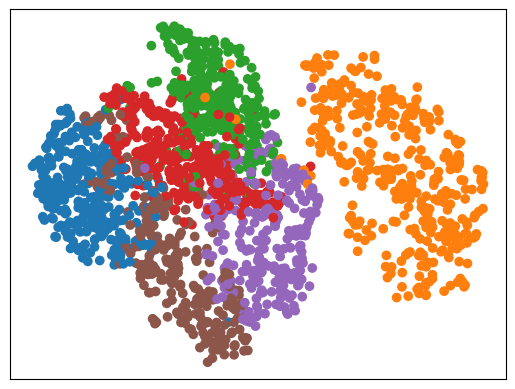

c:\Users\cahar\miniconda3\envs\DeepLearning\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


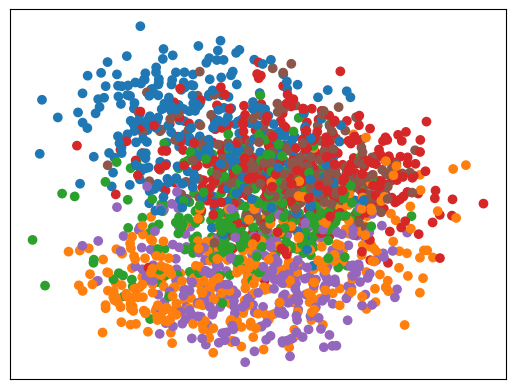

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-33.11126..1.9317498].


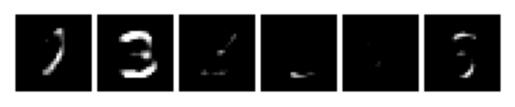

In [4]:
import importlib
import plotting
importlib.reload(plotting)
from plotting import *

def generate_plots(model: GVAE, test_loader, single_graph=None):
    # 0. Collect model test data
    zs = []
    ys = []

    n = 0
    model.eval()

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            n += y.shape[0]

            logits, z_mu, z_logvar, z = model(x)
            zs.append(z.detach().cpu())
            ys.append(y.detach().cpu())
            if n >= 2000:
                break
    zs = torch.cat(zs, dim=0)
    ys = torch.cat(ys, dim=0)

    # 1. Generate T-SNE plot
    if single_graph == None or single_graph == 'tSNE':
        fig, ax = plt.subplots()
        plot_latents(ax, zs, ys, model.latent_dim)   # <-- use the correct plot function
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"plots/gau_{model.latent_dim}_tSNE.svg", format="svg", bbox_inches='tight')
        plt.show()

    # 2. Generate MDS plot
    if single_graph == None or single_graph == 'MDS':
        fig, ax = plt.subplots()
        plot_mds(ax, zs, ys, model.latent_dim)
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"plots/gau_{model.latent_dim}_MDS.svg", format="svg", bbox_inches='tight')
        plt.show()

    # 3. Plot one-hot latent value encoding
    if single_graph == None or single_graph == 'OH':
        fig, ax = plt.subplots()
        plot_latent_dim_wise_reconstruct(ax, model, model.latent_dim, device)
        plt.savefig(f"plots/gau_{model.latent_dim}_one-hot-latent-encoding.png", format="png", bbox_inches='tight')
        plt.show()

generate_plots(model, test_loader)


## Dirichlet implementation 

In [1]:
"""
Implementation of a Dirichelet Variational AutoEncoder using an inverse gamma approximation for a MNIST dataset 
I will use a simple Enconder architecture to start:
Encoder:
    Linear(784 - 500)
    BatchNorm()
    ReLU()
    Linear(400 - 50)
    Softplus()

The Latent Variable Z will have d=50 or d=10 dimensions

Decoder:
    Linear(50 - 500)
    BatchNorm()
    ReLU()
    Linear(500 - 784)
"""

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Uniform
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import math
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from plotting import make_vae_plots
torch.manual_seed(44)

EPS = 1e-8


NUM_EPOCHS = 50

PRIOR_ALPHA = 0.2
# This is the encoder we use, it consists of a single hidden layer with ReLU activations
class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.BatchNorm1d(hidden_dims),
            nn.ReLU(),

            nn.Linear(hidden_dims, latent_dim),
            
        )
    def forward(self, x):
        out = self.net(x)

        # softplus to ensure positive alpha_hat
        alpha_hat = F.softplus(out) + EPS
        alpha_hat = alpha_hat.clamp(min=1e-5, max=1e3) 
        return alpha_hat
# This is the decoder we use, it consists of a Linear Layer, BatchNorm and ReLU activations and lastly a Linear layer to output the logits
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims), 
            nn.BatchNorm1d(hidden_dims), 
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim)
        )

    def forward(self, z):
        logits = self.net(z)
        # return logits (use BCEWithLogitsLoss)
        return logits
#This is the Dirichlet VAE class that combines the encoder and decoder with the inverse gamma reparameterization sampler
class DirVAE(nn.Module):
    def __init__(self, input_dim, enc_hidden_dims, dec_hidden_dims, latent_dim,
                 prior_alpha=None, beta=1.0):
        """
        input_dim: flattened input size (e.g. 28*28)
        enc_hidden_dims:  encoder hidden sizes
        dec_hidden_dims:  decoder hidden sizes
        latent_dim: K

        prior_alpha: vector or scalar for Dirichlet prior concentration alpha (if scalar, replicate)
        beta: rate parameter for Gammas (paper uses beta=1)
        """
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = MLPEncoder(input_dim, enc_hidden_dims, latent_dim)
        self.decoder = Decoder(latent_dim, dec_hidden_dims, input_dim)

        if prior_alpha is None:
            # default weak symmetric prior; user can override
            prior_alpha = torch.ones(latent_dim) * 0.98
        elif torch.is_tensor(prior_alpha):
            if prior_alpha.numel() == 1:
                prior_alpha = prior_alpha.repeat(latent_dim)
        else:
            # numeric scalar
            prior_alpha = torch.tensor(float(prior_alpha)).repeat(latent_dim)
        self.register_buffer('prior_alpha', prior_alpha.float())
        self.beta = float(beta)

    def inverse_gamma_cdf_approx(self, u, alpha):
        """
        Approximate inverse CDF for X ~ Gamma(alpha, beta) using:
        F^{-1}(u; alpha, beta) ≈ beta^{-1} * (u * alpha * Gamma(alpha))^{1/alpha}
        u: uniform samples in (0,1), shape (batch, K)
        alpha: shape (batch, K) or (K,)
        returns: approx gamma samples shape (batch, K)
        """
        # alpha * Gamma(alpha) = alpha * exp(lgamma(alpha))
        #print(alpha.max())
        alpha = alpha.clamp(min=1e-5, max=1e3)
        #print(alpha.max())

        # shapes broadcast
        log_gamma = torch.lgamma(alpha)
        a_gamma = alpha * torch.exp(log_gamma)  # shape (batch, K)
        # clamp u to (eps, 1)
        u = u.clamp(min=EPS, max=1.0 - 1e-12)
        base = u * a_gamma
        # to avoid negative/zero values due to numerical issues, clamp base
        base = base.clamp(min=EPS)
        # power 1/alpha
        samples = (base) ** (1.0 / alpha)

        # divide by beta (rate)
        samples = samples / (self.beta)
        return samples
    
    def sample_dirichlet_from_alpha(self, alpha_hat):
        """
        Given alpha_hat (batch, K), produce reparam samples z on simplex:
          1) draw u ~ Uniform(0,1) per component
          2) approximate gamma sample via inverse Gamma CDF approx
          3) normalize v -> z = v / sum_k v_k
        Returns z (batch, K), v (batch, K), u (for reproducibility)
        """

        # Number of observations
        batch = alpha_hat.shape[0]

        # Uniform draws per component
        u = torch.rand_like(alpha_hat)  # Uniform(0,1), shape(K,)

        v = self.inverse_gamma_cdf_approx(u, alpha_hat)
        # Normalize to get Dirichlet sample
        denom = v.sum(dim=1, keepdim=True).clamp(min=EPS)
        z = v / denom


        return z, v, u
    
    def forward(self, x):
        """
        x: flattened input (batch, input_dim) with values in [0,1] for Bernoulli decoding
        returns: reconstruction logits, z, alpha_hat, v
        """

        # Encoder step to get the posterior parameters
        alpha_hat = self.encoder(x)  # (batch, K)

        # Sample from posterior 
        z, v, u = self.sample_dirichlet_from_alpha(alpha_hat)  # z in simplex

        # Decoder step
        logits = self.decoder(z)  # (batch, input_dim)
        return logits, z, alpha_hat, v
    

# KL divergence between two MultiGamma distributions
def multi_gamma_kl(alpha_hat, prior_alpha):
    """
    KL between MultiGamma(alpha_hat, beta=1) and MultiGamma(prior_alpha, beta=1)
    Per paper (Equation 3):
      KL(Q||P) = sum_k [ log Gamma(alpha_k) - log Gamma(alpha_hat_k)
                         + (alpha_hat_k - alpha_k) * psi(alpha_hat_k) ]

    alpha_hat: (batch, K)
    prior_alpha: (K,) or (batch, K)
    Returns scalar KL (averaged over batch).
    """
    # Broadcast prior_alpha to batch if necessary
    if prior_alpha.dim() == 1:
        prior = prior_alpha.unsqueeze(0).expand_as(alpha_hat)
    else:
        prior = prior_alpha

    # Compute the KL components
    term1 = torch.lgamma(prior) - torch.lgamma(alpha_hat)
    term2 = (alpha_hat - prior) * torch.digamma(alpha_hat)
    kl_comp = term1 + term2
    kl = kl_comp.sum(dim=1)  # per example sum over latent dimensions

    return kl.mean()

# DirVAE ELBO loss function
def dirvae_elbo_loss(model, x):
    """
    Compute negative ELBO (loss to minimize) for Bernoulli decoder.
    x: (batch, input_dim) values in {0,1} or [0,1]
    returns loss (scalar), recon_loss (scalar), kl (scalar), z (tensor)
    """
    logits, z, alpha_hat, v = model(x)

    # Reconstruction: bernoulli likelihood -> BCEWithLogits
    bce = F.binary_cross_entropy_with_logits(logits, x, reduction='none')
    recon_per_sample = bce.sum(dim=1)  # per example reconstruction negative log-likelihood
    
    # Compute the mean for the batch
    recon_loss = recon_per_sample.mean()

    # KL between MultiGamma post (alpha_hat) and prior MultiGamma (prior_alpha)
    kl = multi_gamma_kl(alpha_hat, model.prior_alpha)
    
    # ELBO = E_q[log p(x|z)] - KL -> loss = -ELBO = recon_loss + KL
    loss = recon_loss + kl
    return loss, recon_loss, kl, z

# Training loop for DirVAE
def train_loop(model, optimizer, train_loader, device):
        
        tot_loss = 0.0
        tot_recon = 0.0
        tot_kl = 0.0
        n_samples = 0
        model.train()

        for x, _ in train_loader:
            x = x.to(device)

            #Reset Gradients
            optimizer.zero_grad()

            #Foward Pass
            loss, recon, kl, _ = dirvae_elbo_loss(model, x)

            #BackProp
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            tot_loss += loss.item() * batch_size
            tot_recon += recon.item() * batch_size
            tot_kl += kl.item() * batch_size
            n_samples += batch_size

        mean_loss = tot_loss / n_samples
        mean_recon = tot_recon / n_samples
        mean_kl = tot_kl / n_samples

        print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")

        return mean_loss, mean_recon, mean_kl          
# Testing loop for DirVAE
def test_loop(model, test_loader, device):

    model.eval()
    tot_loss, tot_recon, tot_kl = 0.0, 0.0, 0.0
    n_samples = 0

    with torch.no_grad():
        labels = [] # For visualiation
        zs = [] # For visualization

        for x, label in test_loader:
            x = x.to(device)

            # Foward Pass
            loss, recon, kl, z = dirvae_elbo_loss(model, x)

            batch_size = x.size(0)
            tot_loss += loss.item() * batch_size
            tot_recon += recon.item() * batch_size
            tot_kl += kl.item() * batch_size
            n_samples += batch_size

            labels.append(label)
            zs.append(z)

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples
    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")

    labels = torch.cat(labels, dim=0)
    zs = torch.cat(zs, dim=0)
    
    return mean_loss, mean_recon, mean_kl

def dirichlet_log_prob(z, alpha, eps=1e-8):
    """
    log Dir(z | alpha) = lgamma(sum(alpha)) - sum(lgamma(alpha)) + sum((alpha - 1)*log z)
    """
    z = z.clamp(min=eps)
    alpha_sum = alpha.sum(dim=-1)
    return (
        torch.lgamma(alpha_sum)
        - torch.lgamma(alpha).sum(dim=-1)
        + ((alpha - 1) * z.log()).sum(dim=-1)
    )
    
# Monte Carlo estimate of the marginal negative log-likelihood for DirVAE
@torch.no_grad()
def montecarlo_nll(model, data_loader, device, K=500):
    """
    Monte Carlo (importance-weighted) estimate of the marginal log-likelihood:
        p(x) ≈ (1/K) Σ_i p(x|z_i)p(z_i)/q(z_i)
    Returns the mean NLL (nats per image) as in Proposition A.1 of DirVAE.
    """
    model.eval()
    total_nll = 0.0
    n_samples = 0

    for x, _ in data_loader:
        x = x.to(device)
        B = x.size(0)

        # ---- 1) Encode: q(z|x) = Dirichlet(alpha_hat)
        alpha_hat = model.encoder(x)  # (B, latent_dim)

        # ---- 2) Sample z_i ~ q(z|x) using model’s internal Dirichlet sampler
        # repeat alpha_hat K times (for K importance samples)
        alpha_rep = alpha_hat.unsqueeze(0).expand(K, -1, -1).contiguous().view(-1, alpha_hat.size(1))
        z, v, u = model.sample_dirichlet_from_alpha(alpha_rep)  # (K*B, latent_dim)
        z = z.view(K, B, -1)

        # ---- 3) Compute p(x|z_i)
        logits = model.decoder(z.view(-1, model.latent_dim))  # (K*B, input_dim)
        log_p_x_given_z = -F.binary_cross_entropy_with_logits(
            logits, x.repeat(K, 1), reduction="none"
        ).sum(dim=1)
        log_p_x_given_z = log_p_x_given_z.view(K, B)

        # ---- 4) Compute p(z_i) and q(z_i|x)
        prior_alpha = model.prior_alpha.to(device).view(1, 1, -1).expand_as(z)
        post_alpha = alpha_hat.view(1, B, -1).expand_as(z)
        log_p_z = dirichlet_log_prob(z, prior_alpha)  # (K, B)
        log_q_z = dirichlet_log_prob(z, post_alpha)   # (K, B)

        # ---- 5) Importance weights w_i = p(x|z_i)p(z_i)/q(z_i)
        log_w = log_p_x_given_z + log_p_z - log_q_z   # (K, B)

        # ---- 6) Monte Carlo marginal log-likelihood (log-sum-exp trick)
        log_w_max, _ = torch.max(log_w, dim=0, keepdim=True)
        log_p_x = log_w_max.squeeze(0) + torch.log(
            torch.exp(log_w - log_w_max).mean(dim=0)
        ) - math.log(K)

        # ---- 7) Average over batch
        batch_nll = (-log_p_x).sum().item()
        total_nll += batch_nll
        n_samples += B

    mean_nll = total_nll / n_samples
    print(f"Estimated NLL (Monte Carlo, K={K}): {mean_nll:.4f}")
    return mean_nll
# Training function to train DirVAE from scratch
def train_from_scratch(model, train_loader, test_loader, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(0, NUM_EPOCHS):
        print(f"Epoch {epoch}")
        print("--------")
        mean_train_loss, mean_train_recon, mean_train_kl = train_loop(model, optimizer, train_loader, device)
        print("")
 
    #### Small Visualization
        if epoch % 5 == 0:
            model.eval()
            with torch.no_grad():

                batch, _ = next(iter(test_loader))
                batch = batch[:16].to(device)
                x = batch  
                # Forward pass (posterior sample)
                logits, z, alpha_hat, _ = model(x)
                recon_imgs = torch.sigmoid(logits).view(-1, 1, 28, 28)

                # Stack originals (top) and reconstructions (bottom)
                comparison = torch.cat([x.view(-1, 1, 28, 28), recon_imgs])
                torchvision.utils.save_image(
                    comparison,
                    f"saves/DirVAE/recon_images/recon_test_epoch_{epoch:02d}.png",
                    nrow=16
                )
                
    return model


<h3>This is the main training loop<h3>
<h5>Here we use the functions above to load the dataset, filter it by how many numbers we want to train on, instanciate the model and the dataloaders and training the model<h5>

In [2]:


if torch.cuda.is_available():
    device = torch.device("cuda")
#### IMPORTANT, the torch.gamma and torch.digamma explode when using mps (floating point errors)
#  elif torch.backends.mps.is_available():
#  device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Current device:", device)
    
# Simple binarization transform
transform = T.Compose([
T.ToTensor(),         
lambda t: t.view(-1)   
    ])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def filter_mnist(dataset, keep):
    mask = torch.isin(dataset.targets, torch.tensor(keep))
    dataset.data = dataset.data[mask]
    dataset.targets = dataset.targets[mask]
    return dataset

trainset = filter_mnist(trainset, keep=[1,2,4])
testset = filter_mnist(testset, keep=[1,2,4])

train_loader = DataLoader(trainset, batch_size=100, shuffle=True, num_workers=0)
test_loader = DataLoader(testset, batch_size=100, shuffle=True, num_workers = 0)

input_dim = 28 * 28
latent_dim = 3
model = DirVAE(input_dim=input_dim,
                enc_hidden_dims=500,
                dec_hidden_dims=500,
                latent_dim=latent_dim,
                prior_alpha=PRIOR_ALPHA).to(device)

    # Check if trained model exists
if os.path.exists(f"saves/DirVAE/DirVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}_a_{PRIOR_ALPHA}.pth"):
    model.load_state_dict(torch.load(f"saves/DirVAE/DirVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}_a_{PRIOR_ALPHA}.pth", weights_only=True, map_location=device))
else:
    model = train_from_scratch(model, train_loader, test_loader, device)
    torch.save(model.state_dict(), f"saves/DirVAE/DirVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}_a_{PRIOR_ALPHA}.pth")
    
print("-------------")
print("Test Results:")
mean_test_loss, mean_test_recon, mean_test_kl = test_loop(model, test_loader, device)
montecarlo_nll(model, test_loader, device, K=500)

Current device: cpu
-------------
Test Results:
Negative ELBO: 140.5348 | Recon Loss: 130.6489 | KL: 9.8858
Estimated NLL (Monte Carlo, K=500): 133.1291


133.12913821848207

<h3>Here we plot the results of the model <h3>

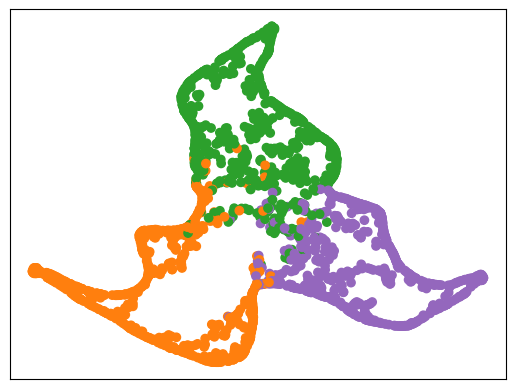

c:\Users\cahar\miniconda3\envs\DeepLearning\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


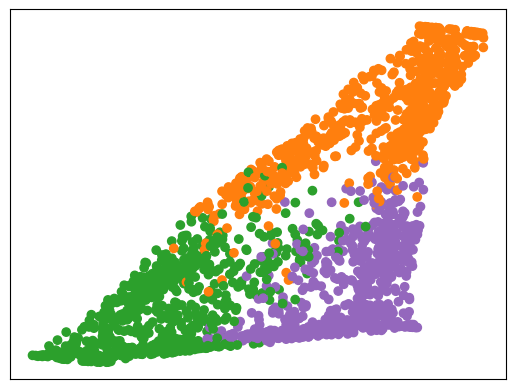

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-46.563602..4.80035].


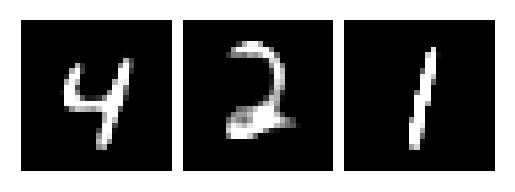

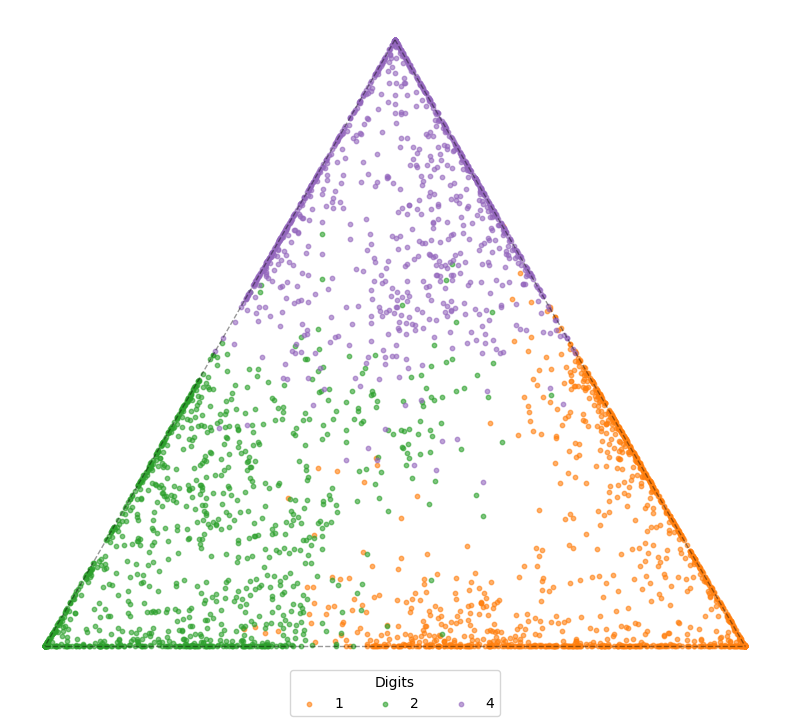

In [3]:
import importlib
import plotting
importlib.reload(plotting)
from plotting import *

import plots.simplex
importlib.reload(plots.simplex)
from plots.simplex import plot_mnist_simplex


def generate_plots(model: DirVAE, test_loader, single_graph=None):
    # 0. Collect model test data
    zs = []
    ys = []

    n = 0
    model.eval()

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            n += y.shape[0]

            logits, z, alpha_hat, v = model(x)
            zs.append(z.detach().cpu())
            ys.append(y.detach().cpu())
            if n >= 2000:
                break
    zs = torch.cat(zs, dim=0)
    ys = torch.cat(ys, dim=0)

    # 1. Generate T-SNE plot
    if single_graph == None or single_graph == 'tSNE':
        fig, ax = plt.subplots()
        plot_latents(ax, zs, ys, model.latent_dim)   # <-- use the correct plot function
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"plots/dir_{model.latent_dim}_tSNE.svg", format="svg", bbox_inches='tight')
        plt.show()

    # 2. Generate MDS plot
    if single_graph == None or single_graph == 'MDS':
        fig, ax = plt.subplots()
        plot_mds(ax, zs, ys, model.latent_dim)
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"plots/dir_{model.latent_dim}_MDS.svg", format="svg", bbox_inches='tight')
        plt.show()

    # 3. Plot one-hot latent value encoding
    if single_graph == None or single_graph == 'OH':
        fig, ax = plt.subplots()
        plot_latent_dim_wise_reconstruct(ax, model, model.latent_dim, device)
        plt.savefig(f"plots/dir_{model.latent_dim}_one-hot-latent-encoding.png", format="png", bbox_inches='tight')
        plt.show()

    # 4. Plot simplex visualization
    if single_graph == None or single_graph == 'Simplex':
        latents = []
        labels = []
        for x, y in test_loader:
            x = x.to(device)
            with torch.no_grad():
                logits, z, alpha_hat, v = model(x)
            latents.append(z.cpu().numpy())
            labels.append(y.numpy())

        latent_matrix = np.vstack(latents)
        labels = np.hstack(labels)

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_aspect('equal')
        ax.axis('off')
        plot_mnist_simplex(latent_matrix, labels, latent_dim, ax=ax)
        plt.tight_layout()
        plt.savefig(f"plots/dir_{model.latent_dim}_simplex.svg", format="svg", bbox_inches='tight')
        plt.show()

generate_plots(model, test_loader)


## Continuous Categorical VAE implementation

# Ordered Rejection Sampler

-------------
Test Results:
Negative ELBO: 198.5019 | Recon Loss: 175.6891 | KL: 30.4171
Estimated NLL (Monte Carlo, K=500): 194.8735
Plotting tSNE graph...
Plotting MDS graph...


c:\Users\cahar\miniconda3\envs\DeepLearning\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-20.221645..4.701827].


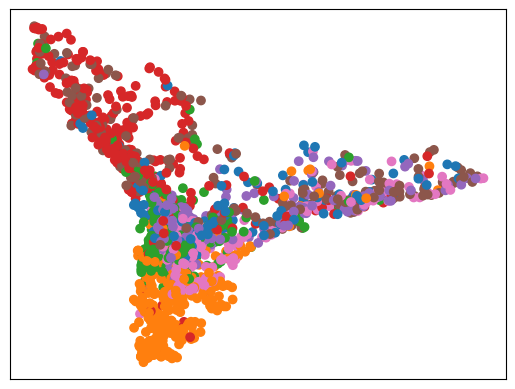

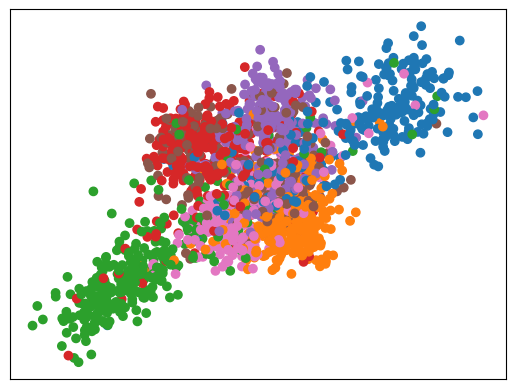

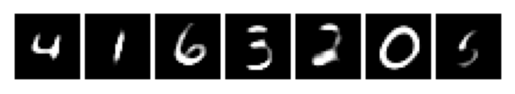

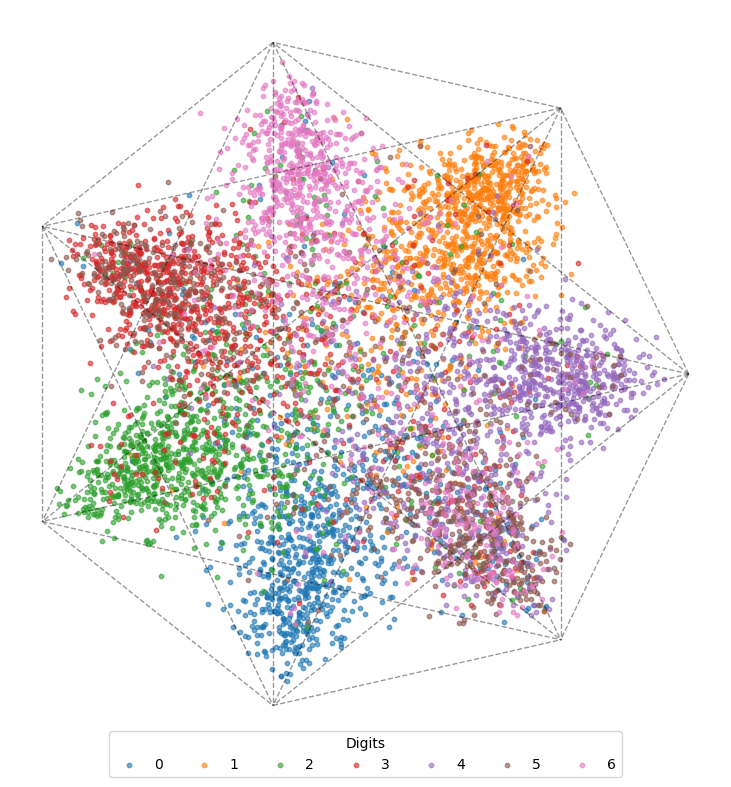

In [7]:
# %%
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch import Tensor
import os
import importlib
import plotting
import numpy as np
importlib.reload(plotting)
from plotting import make_new_vae_plots
import compare
importlib.reload(compare)
from compare import save_performance 
import random

# --- CONSOLIDATED EPSILON ---
EPS = 1e-6  # small constant to avoid numerical issues
NUM_EPOCHS = 50 # number of training epochs
learning_rate = 1e-3 # learning rate for optimizer
hidden_dim = 512 # hidden dimension for encoder/decoder
numbers = 7 # numbers to use from MNIST

#take learning rate and hidden dim from command line input



def set_seed(seed):
    """
    Sets the seed for reproducibility across all libraries.
    """
    # 1. Python's built-in random library
    random.seed(seed)
    
    # 2. NumPy (used for your annealing schedule)
    np.random.seed(seed)
    
    # 3. PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 4. PyTorch (GPU)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # If using multiple GPUs
    
    # 5. Deterministic Algorithms (Crucial for CUDA)
    # This ensures that convolution algorithms are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # Disables auto-tuning for speed (which introduces noise)
    
    print(f"Random Seed set to: {seed}")

# ======================================================================
#  HELPER FUNCTIONS (Continuous Categorical Distribution)
# ======================================================================

def inv_cdf_torch(u, l):
    """
    Inverse CDF of the continuous Bernoulli distribution.
    [cite_start]Used for reparameterization in CC sampling[cite: 600].
    """
    near_half = (l > 0.499) & (l < 0.501)
    safe_l = l.clamp(EPS, 1 - EPS)
    u = u.clamp(EPS, 1 - EPS)
    
    num = torch.log(u * (2 * safe_l - 1) + 1 - safe_l) - torch.log(1 - safe_l)
    den = torch.log(safe_l) - torch.log(1 - safe_l)
    x = num / den
    return torch.where(near_half, u, x)


# This is the ordered rejection sampler for the Continuous Categorical distribution
# It is here we use the "Max Attempts" modification discussed in the report
def sample_cc_ordered_reparam(lam, debug=False):
    """
    Ordered Rejection Sampler (Algorithm 1 in the CC paper [cite: 164]).
    Sorts lambda (lam) to maximize acceptance rate.
    Includes diagnostic printing to track sampler efficiency.
    """
    B, K = lam.shape
    
    # 1. Sort lambda descending (largest to smallest) [cite: 166]
    lam_sorted, indices = torch.sort(lam, dim=1, descending=True)
    
    # 2. Prepare Parameters (CB params = lam_i / (lam_i + lam_1))
    lam_1 = lam_sorted[:, 0].unsqueeze(1) 
    lam_rest = lam_sorted[:, 1:] 
    
    cb_params = lam_rest / (lam_rest + lam_1 + EPS)

    final_x_rest = torch.zeros_like(lam_rest)
    active_mask = torch.ones(B, dtype=torch.bool, device=lam.device)
    max_attempts = 1000
    
    # --- MODIFICATION START ---
    actual_attempts = 0
    
    # Change range(max_attempts) to enumerate or use 'attempt' variable
    for attempt in range(max_attempts):
        actual_attempts = attempt + 1
        
        if not active_mask.any():
            break
        
        n_active = active_mask.sum()
        u = torch.rand(n_active, K-1, device=lam.device, dtype=lam.dtype)
        
        active_params = cb_params[active_mask]
        # 4. Inverse CDF (Differentiable) [cite: 600]
        x_cand = inv_cdf_torch(u, active_params) 
        
        # 5. Check constraint (Sum <= 1)
        sums = x_cand.sum(dim=1)
        accepted_now = (sums <= 1.0)
        
        # 6. Update tensors
        active_indices = torch.nonzero(active_mask).squeeze(-1)
        accepted_indices = active_indices[accepted_now]
        
        if accepted_indices.numel() > 0:
            final_x_rest[accepted_indices] = x_cand[accepted_now]
            # Clone mask before modification to satisfy autograd
            active_mask = active_mask.clone()
            active_mask[accepted_indices] = False
            
    # --- DIAGNOSTICS ---
    if debug:
        # Check how many samples NEVER found a solution
        failed_count = active_mask.sum().item()

        # If we hit the max or have failures, print a warning
        if actual_attempts >= max_attempts or failed_count > 0:
            print(f"!! SAMPLER WARNING !! K={K}")
            print(f"   Max Attempts Used: {actual_attempts}/{max_attempts}")
            print(f"   Failed Samples (zeros returned): {failed_count}/{B}")
            print(f"   Acceptance Rate approx: {1.0 / actual_attempts:.5f}")
            
    # --- MODIFICATION END ---
            
    # 7. Calculate the Slack Variable: x_1 = 1 - sum(x_rest)
    # Note: If failed, final_x_rest is 0, so x_1 becomes 1.0 (corner solution)[cite: 176]
    x_1 = (1.0 - final_x_rest.sum(dim=1, keepdim=True)).clamp(min=EPS)
    x_sorted = torch.cat([x_1, final_x_rest], dim=1)
    
    # 8. Unsort back to original order
    x_final = torch.zeros_like(lam)
    x_final.scatter_(1, indices, x_sorted)
    
    return x_final

def lambda_to_eta(lam: Tensor) -> Tensor:
    #[cite_start]"""Converts mean parameter lambda [B, K] to natural parameter eta [B, K-1][cite: 91]."""
    lam = lam.clamp(min=EPS, max=1.0) 
    last = lam[:, -1].unsqueeze(1)
    eta = torch.log(lam / (last + EPS))
    return eta[:, :-1]

# This is the log normalizer calculation using the formula from the paper
def cc_log_norm_const_torch(eta: Tensor) -> Tensor:
    """
    [cite_start]Calculates log C(eta) using the Exact Formula (Eq 7 in the paper [cite: 124]).
    [cite_start]Note: Calculation is done in double precision for stability[cite: 134].
    """
    original_dtype = eta.dtype
    eta = eta.double()

    B, K_minus_1 = eta.shape
    K = K_minus_1 + 1
    device = eta.device
    
    # [cite_start]1. Construct full eta (append 0 for the Kth component) [cite: 92]
    eta_full = torch.cat([eta, torch.zeros(B, 1, device=device, dtype=eta.dtype)], dim=1)
    
    # 2. Add Jitter
    jitter = torch.arange(K, device=device) * 1e-5
    eta_full = eta_full + jitter.unsqueeze(0)

    # 3. Compute the denominator product: prod_{i!=k} (eta_i - eta_k) 
    eta_i = eta_full.unsqueeze(1) 
    eta_k = eta_full.unsqueeze(2)
    diffs = eta_i - eta_k
    
    eye_mask = torch.eye(K, device=device).bool().unsqueeze(0).expand(B, -1, -1)
    diffs[eye_mask] = 1.0 
    
    log_diffs_abs = diffs.abs().log()
    diffs_sign = diffs.sign()
    
    log_denom = log_diffs_abs.sum(dim=1) 
    denom_sign = diffs_sign.prod(dim=1) 
    
    log_terms_mag = eta_full - log_denom
    terms_sign = denom_sign
    
    # 4. Sum the terms: S = sum_k (T_k)
    max_log_mag, _ = log_terms_mag.max(dim=1, keepdim=True)
    sum_scaled = torch.sum(terms_sign * torch.exp(log_terms_mag - max_log_mag), dim=1)
    
    # 5. Multiply by (-1)^(K+1) 
    global_sign = (-1)**(K + 1)
    total_sum_signed = global_sign * sum_scaled
    
    log_inv_C = max_log_mag.squeeze() + torch.log(total_sum_signed.clamp(min=EPS))
    
    # Return log C = - log(C^-1)
    return -log_inv_C.to(dtype=original_dtype)

def cc_log_prob_torch(sample: Tensor, eta: Tensor) -> Tensor:
    """
    [cite_start]Calculates the log-density p(z | eta) = eta^T * z + log C(eta)[cite: 94].
    sample: [B, K], eta: [B, K-1]
    Returns: [B]
    """
    n, K_minus_1 = eta.shape
    aug_eta = torch.cat([eta, torch.zeros(n, 1, device=eta.device, dtype=eta.dtype)], dim=-1)
    
    # Exponent term: eta^T * z
    exponent = torch.sum(sample * aug_eta, dim=1) 
    
    # Log Normalizer term
    log_norm_const = cc_log_norm_const_torch(eta)
    
    return exponent + log_norm_const 
    

# ======================================================================
# 2. MODEL DEFINITIONS
# ======================================================================
# this is the encoder and decoder architecture for CCVAE
class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.BatchNorm1d(hidden_dims),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dims),
            nn.Linear(hidden_dims, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims, bias=False),
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim, bias=False)
            
        )


    def forward(self, z):
        return self.net(z)
# this is the CCVAE model class
class CCVAE(nn.Module):
    def __init__(self, input_dim, enc_hidden_dims, dec_hidden_dims, latent_dim):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.encoder = MLPEncoder(input_dim, enc_hidden_dims, latent_dim)
        self.decoder = Decoder(latent_dim, dec_hidden_dims, input_dim)

        # Set explore_epochs higher for a slower T annealing schedule
        self.explore_epochs = 100 
        self.current_epoch = 1

    def forward(self, x):
        annealing_rate = -0.005
        # Gradually make the softmax data more strengthen model predictions! 
        tau = np.maximum(0.5, 1.0 * np.exp(annealing_rate * self.current_epoch))

        lam_logits = self.encoder(x) # lam is the mean parameter [B, K]

        lam = F.softmax(lam_logits/tau, dim=1)

        # Directly use the reparameterized sampler
        z = sample_cc_ordered_reparam(lam) 

        recon_logits = self.decoder(z)
        return recon_logits, lam, z

# ======================================================================
# 3. VARIATIONAL INFERENCE CLASS (The Loss Function Module with Free-Bits)
# ======================================================================
# this is the variational inference class that computes the beta-ELBO loss with KL warmup and free-bits
class VariationalInference(nn.Module):
    """
    Computes the beta-ELBO loss for the CCVAE based on model outputs, 
    including KL Warmup and Free-Bits regularization.
    """
    def __init__(self, zero_beta_epochs:float,  base_beta: float, warmup_epochs: int, max_beta: float):
        super().__init__()
        self.zero_beta_epochs = zero_beta_epochs
        self.base_beta = base_beta
        # Use a more robust warmup period
        self.warmup_epochs = warmup_epochs
        self.max_beta = max_beta

    def get_beta(self, epoch: int) -> float:
        """
        Calculates the annealing beta for KL divergence using a three-stage schedule:
        1. Zero Beta (Pure Recon)
        2. Linear Ramp-up
        3. Constant Final Beta
        """
        
        if epoch <= self.zero_beta_epochs:
            # Stage 1: Zero beta (pure reconstruction phase)
            beta = 0.0
            
        elif epoch < self.zero_beta_epochs + self.warmup_epochs:
            # Stage 2: Linear ramp up
            # Calculate progress starting from the end of the zero-beta phase
            progress = (epoch - self.zero_beta_epochs) / self.warmup_epochs
            beta = self.base_beta * progress
            
        else:
            # Stage 3: Constant beta (stable phase)
            beta = self.base_beta
            
        return min(self.max_beta, beta)

    # Note: The forward method (which is not shown but assumed to be correct) 
    # must be using self.get_beta(epoch) to calculate the final loss coefficient.
    def forward(self, x: Tensor, logits_dec: Tensor, lam: Tensor, z: Tensor, epoch: int):
        K = lam.size(1) 
        
        # --- 1. Reconstruction Loss (Negative Log-Likelihood) ---
        bce = F.binary_cross_entropy_with_logits(logits_dec, x, reduction='none')
        recon_loss = bce.sum(dim=1).mean() # Mean over batch

        # --- 2. Monte Carlo KL Divergence ---
        # Posterior Parameters (eta_q) and Prior Parameters (eta_p)
        eta_q = lambda_to_eta(lam)
        prior_lam = torch.full_like(lam, 1.0 / K)
        eta_p = lambda_to_eta(prior_lam)

        # Log densities p(z|q) and p(z|p)
        log_q = cc_log_prob_torch(z, eta_q) # [B]
        log_p = cc_log_prob_torch(z, eta_p) # [B]

        # KL = E_z [log q(z) - log p(z)]
        kl = (log_q - log_p).mean() # True KL (for logging)

        # --- 4. β-ELBO Loss ---
        beta = self.get_beta(epoch)
        
        # Loss = Recon Loss + beta * KL_penalty (Minimizing the Negative ELBO)
        loss = recon_loss + beta * kl
        
        return loss, recon_loss, kl
    
# Monte Carlo estimate of the marginal negative log-likelihood for CCVAE
def montecarlo_nll(model, data_loader, device, K=500):
    """
    Monte Carlo (importance-weighted) estimate of the marginal log-likelihood for CCVAE:
        p(x) ≈ (1/K) Σ_i p(x|z_i)p(z_i)/q(z_i)
    
    Adapts the Continuous Categorical logic (lambda -> eta -> log_prob).
    """
    model.eval()
    total_nll = 0.0
    n_samples = 0
    
    # Ensure we have the latent dim
    latent_dim = model.latent_dim

    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device)
            B = x.size(0)

            # ---- 1) Encode: q(z|x) parameters (lambda)
            # Get logits from encoder
            lam_logits = model.encoder(x) 
            # Convert to mean parameter lambda [B, latent_dim]
            lam = F.softmax(lam_logits, dim=1)

            # ---- 2) Prepare for K importance samples
            # We repeat the parameters K times to batch the computation
            # Shape becomes [K*B, latent_dim]
            # We repeat such that the batch structure is [Sample 1 for Batch, Sample 2 for Batch...]
            lam_expanded = lam.repeat(K, 1) 

            # ---- 3) Sample z ~ q(z|x) using CC sampler
            # Use the global sampling function you defined
            z = sample_cc_ordered_reparam(lam_expanded) # [K*B, latent_dim]

            # ---- 4) Compute p(x|z_i) (Reconstruction Likelihood)
            # Decode all K*B samples
            logits_dec = model.decoder(z) # [K*B, input_dim]
            
            # Expand x to match the decoder output: [K*B, input_dim]
            x_expanded = x.repeat(K, 1)
            
            # Calculate Negative Log Likelihood (Reconstruction Loss) per sample
            # We sum over pixels (dim 1) but keep the K*B dimension
            recon_loss = F.binary_cross_entropy_with_logits(
                logits_dec, x_expanded, reduction='none'
            ).sum(dim=1)
            
            # log p(x|z) is negative recon loss
            log_p_x_given_z = -recon_loss # [K*B]

            # ---- 5) Compute p(z_i) and q(z_i|x) probabilities
            # We need to convert lambda to eta (natural params) for the log_prob function
            
            # Posterior eta: q(z|x)
            eta_q = lambda_to_eta(lam_expanded) # [K*B, latent_dim-1]
            
            # Prior eta: p(z) -> Uniform on simplex -> lambda_i = 1/K
            prior_lam = torch.full_like(lam_expanded, 1.0 / latent_dim)
            eta_p = lambda_to_eta(prior_lam)    # [K*B, latent_dim-1]

            # Calculate densities using your global CC function
            log_q_z = cc_log_prob_torch(z, eta_q) # [K*B]
            log_p_z = cc_log_prob_torch(z, eta_p) # [K*B]

            # ---- 6) Importance weights calculation
            # Reshape everything to [K, B] to handle the summation over K
            log_p_x_given_z = log_p_x_given_z.view(K, B)
            log_p_z = log_p_z.view(K, B)
            log_q_z = log_q_z.view(K, B)
            
            # log w_i = log p(x|z) + log p(z) - log q(z|x)
            log_w = log_p_x_given_z + log_p_z - log_q_z   # [K, B]

            # ---- 7) Log-Sum-Exp Trick for numerical stability
            # log(1/K * sum(exp(log_w))) = -log(K) + log(sum(exp(log_w)))
            #                            = -log(K) + max(w) + log(sum(exp(w - max(w))))
            
            log_w_max, _ = torch.max(log_w, dim=0, keepdim=True) # Max over K samples
            
            # Compute the log marginal likelihood estimate
            log_p_x = log_w_max.squeeze(0) + torch.log(
                torch.exp(log_w - log_w_max).mean(dim=0) # Mean performs the (1/K * sum)
            )

            # ---- 8) Aggregate NLL (nats)
            # NLL is negative log probability
            batch_nll = (-log_p_x).sum().item()
            total_nll += batch_nll
            n_samples += B

    mean_nll = total_nll / n_samples
    print(f"Estimated NLL (Monte Carlo, K={K}): {mean_nll:.4f}")
    return mean_nll


# ==========================================
# 4. TRAINING UTILS (Loss  and Loops)
# ==========================================
# this function computes the loss for CCVAE using the VI module
def ccvae_loss(model: 'CCVAE', vi: VariationalInference, x: Tensor, epoch: int):
    """Performs model forward pass and uses VI module to calculate loss."""
    logits_dec, lam, z = model(x) 
    loss, recon_loss, kl = vi(x, logits_dec, lam, z, epoch)
    return loss, recon_loss, kl, z
# training loop for CCVAE
def train_loop(model: 'CCVAE', vi: VariationalInference, optimizer, train_loader, device):
    model.train()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0

    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        
        loss, recon, kl, _ = ccvae_loss(model, vi, x, model.current_epoch)
        
        loss.backward()
        optimizer.step()
        
        batch_size = x.size(0)
        tot_loss += loss.item() * batch_size
        tot_recon += recon.item() * batch_size
        tot_kl += kl.item() * batch_size
        n_samples += batch_size

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples
    
    loss_data.append(mean_loss)
    recon_data.append(mean_recon)
    kl_data.append(mean_kl)
    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")
    # make_new_vae_plots(model, loss_data, recon_data, kl_data, model(next(iter(train_loader))[0].to(device))[0])
    return mean_loss, mean_recon, mean_kl

loss_data = []
recon_data = []
kl_data = []
# testing loop for CCVAE
def test_loop(model: 'CCVAE', vi: VariationalInference, test_loader, device):
    model.eval()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0
    with torch.no_grad():
        for x, label in test_loader:
            x = x.to(device)
            loss, recon, kl, z = ccvae_loss(model, vi, x, model.current_epoch)
            b = x.size(0)
            tot_loss += loss.item() * b
            tot_recon += recon.item() * b
            tot_kl += kl.item() * b
            n_samples += b

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples

    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")
    # make_new_vae_plots(model, loss_data, recon_data, kl_data, model(next(iter(test_loader))[0].to(device))[0], overwrite=False) # to avoid the graph being gone
    return mean_loss, mean_recon, mean_kl
# function to train CCVAE from scratch
def train_from_scratch(model: 'CCVAE',vi:VariationalInference, train_loader, test_loader, device):
    # Instantiate the VariationalInference module with Free-Bits and a longer Warmup
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(0, NUM_EPOCHS+1):
        model.current_epoch = epoch
        print(f"Epoch {epoch}/{NUM_EPOCHS}:")
        print("--------")
        train_loop(model, vi, optimizer, train_loader, device) 
        # print("")
        
        if epoch % 5 == 0:
            test_loop(model, vi, test_loader, device) 
            model.eval()
            with torch.no_grad():
                batch, _ = next(iter(test_loader))
                batch = batch[:16].to(device)
                logits_dec, _, _ = model(batch)
                recon_imgs = torch.sigmoid(logits_dec).view(-1, 1, 28, 28)
                comparison = torch.cat([batch.view(-1, 1, 28, 28), recon_imgs])

                os.makedirs("saves/CCVAE/recon_images", exist_ok=True)
                torchvision.utils.save_image(
                    comparison,
                    f"saves/CCVAE/recon_images/recon_test_epoch_{epoch:02d}.png",
                    nrow=16
                )
    return model


# this is the main training script for CCVAE
# Set random seed for reproducibility
set_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
#### IMPORTANT, the torch.gamma and torch.digamma explode when using mps (floating point errors)
#  elif torch.backends.mps.is_available():
#  device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Current device:", device)
print(f"Using learning rate: {learning_rate}, hidden dim: {hidden_dim}")

# Simple binarization transform
transform = T.Compose([
T.ToTensor(), 
lambda t: t.view(-1) 
    ])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def filter_mnist(dataset, keep):
    mask = torch.isin(dataset.targets, torch.tensor(keep))
    dataset.data = dataset.data[mask]
    dataset.targets = dataset.targets[mask]
    return dataset

nums = list(range(0, numbers))
latent_dim = len(nums)

    # Filter for digits 1, 2, and 4 if the latent_dimension = 3
if latent_dim == 3:
    nums = [1,2,4]

trainset = filter_mnist(trainset, keep=nums)
testset = filter_mnist(testset, keep=nums)
train_loader = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(testset, batch_size=256, shuffle=True, num_workers = 0)

input_dim = 28 * 28

print(f"Training CCVAE with latent dim: {latent_dim}")
print(f"used numbers: {nums}")
print(f"epochs : {NUM_EPOCHS}")
model = CCVAE(input_dim=input_dim,
                enc_hidden_dims=hidden_dim,
                dec_hidden_dims=hidden_dim,
                latent_dim=latent_dim).to(device)

vi = VariationalInference(
        zero_beta_epochs = 10,
        base_beta=0.75, 
        warmup_epochs=20,
        max_beta=1.0,
    ).to(device)

test_name = f"hyperparam_test_lr_{learning_rate}_hd_{hidden_dim}"  # Set to None to train from scratch without loading/saving
skip_load = False # if true, do not load a model

loss_data = []
recon_data = []
kl_data = []


path = f"saves/CCVAE/ordered/{test_name}"
performance_path = f"saves/CCVAE/ordered/{test_name}/performance"
plots_path =  f"saves/CCVAE/ordered/{test_name}/plots"

# Check if trained model exists
if not skip_load and os.path.exists(f"{path}/CCVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}.pth"): # If skip load is false and the model exists
        # Load the model
        model.load_state_dict(torch.load(f"{path}/CCVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}.pth", weights_only=True, map_location=device))
else:
    if not os.path.exists(path):
            os.makedirs(path, exist_ok=True)
    if not os.path.exists(performance_path):
        os.makedirs(performance_path, exist_ok = True)
    
    if not os.path.exists(plots_path):
        os.makedirs(plots_path, exist_ok = True)

    model = train_from_scratch(model, vi, train_loader, test_loader, device)
    save_performance(f'{performance_path}/performance_e_{NUM_EPOCHS}_ld_{latent_dim}', loss_data, recon_data, kl_data)
    make_new_vae_plots(model, loss_data, recon_data, kl_data, model(next(iter(test_loader))[0].to(device))[0], f'{performance_path}/performance_e_{NUM_EPOCHS}_ld_{latent_dim}.png') # save final graph
    torch.save(model.state_dict(), f"{path}/CCVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}.pth")

print("-------------")
print("Test Results:")
# Pass the VI object to test_loop
mean_test_loss, mean_test_recon, mean_test_kl = test_loop(model, vi, test_loader, device)

montecarlo_nll(model, test_loader, device, K=500)


import importlib
import plotting
importlib.reload(plotting)
from plotting import *

import plots.simplex
importlib.reload(plots.simplex)
from plots.simplex import plot_mnist_simplex

# this function generates all the required plots for CCVAE
def generate_plots(model: CCVAE, test_loader, single_graph=None):
    # 0. Collect model test data
    zs = []
    ys = []

    n = 0
    model.eval()

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            n += y.shape[0]

            recon_logits, lam, z = model(x) 
            zs.append(z.detach().cpu())
            ys.append(y.detach().cpu())
            if n >= 2000:
                break
    zs = torch.cat(zs, dim=0)
    ys = torch.cat(ys, dim=0)

    # 1. Generate T-SNE plot
    if single_graph == None or single_graph == 'tSNE':
        print("Plotting tSNE graph...")
        fig, ax = plt.subplots()
        plot_latents(ax, zs, ys, model.latent_dim)   # <-- use the correct plot function
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"{plots_path}/cc_{model.latent_dim}_tSNE.svg", format="svg", bbox_inches='tight')
        #plt.show()

    # 2. Generate MDS plot
    if single_graph == None or single_graph == 'MDS':
        print("Plotting MDS graph...")
        fig, ax = plt.subplots()
        plot_mds(ax, zs, ys, model.latent_dim)
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"{plots_path}/cc_{model.latent_dim}_MDS.svg", format="svg", bbox_inches='tight')
        #plt.show()

    # 3. Plot one-hot latent value encoding
    if single_graph == None or single_graph == 'OH':
        fig, ax = plt.subplots()
        plot_latent_dim_wise_reconstruct(ax, model, model.latent_dim, device)
        plt.savefig(f"{plots_path}/cc_{model.latent_dim}_one-hot-latent-encoding.png", format="png", bbox_inches='tight')
        #plt.show()

    # 4. Plot simplex visualization
    if single_graph == None or single_graph == 'Simplex':
        latents = []
        labels = []
        for x, y in test_loader:
            x = x.to(device)
            with torch.no_grad():
                recon_logits, lam, z = model(x) 
            latents.append(z.cpu().numpy())
            labels.append(y.numpy())

        latent_matrix = np.vstack(latents)
        labels = np.hstack(labels)

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_aspect('equal')
        ax.axis('off')
        plot_mnist_simplex(latent_matrix, labels, latent_dim, ax=ax)
        plt.tight_layout()
        plt.savefig(f"{plots_path}/cc_{model.latent_dim}_simplex.svg", format="svg", bbox_inches='tight')
        #plt.show()

generate_plots(model, test_loader)

# Hybrid sampler that uses both the permutation sampler and the ordered rejection sampler 

Random Seed set to: 42
Current device: cpu
Using learning rate: 0.001, hidden dim: 512
Training CCVAE with latent dim: 7
used numbers: [0, 1, 2, 3, 4, 5, 6]
epochs : 50
-------------
Test Results:
Negative ELBO: 176.2834 | Recon Loss: 176.2834 | KL: 30.7532
Plotting tSNE graph...


KeyboardInterrupt: 

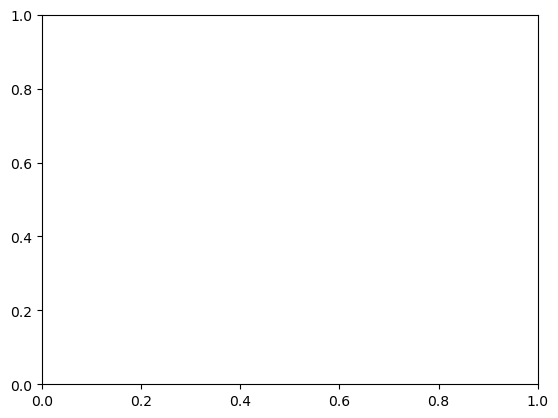

In [ ]:
# %%
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch import Tensor
import os
import importlib
import plotting
import numpy as np
importlib.reload(plotting)
from plotting import make_new_vae_plots
import compare
importlib.reload(compare)
from compare import save_performance 
import random

# --- CONSOLIDATED EPSILON ---
EPS = 1e-6
NUM_EPOCHS = 50
learning_rate = 1e-3
hidden_dim = 512
total_iterations = 0
total_attempts = 50000



def set_seed(seed):
    """
    Sets the seed for reproducibility across all libraries.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random Seed set to: {seed}")


# ======================================================================
#  HELPER FUNCTIONS
# ======================================================================

def inv_cdf_torch(u, l):
    """
    Inverse CDF of the continuous Bernoulli distribution.
    CRITICAL FIX: This version prevents NaN generation.
    """
    u = u.clamp(EPS, 1 - EPS)
    l = l.clamp(EPS, 1 - EPS)
    
    mask_near_half = (l > 0.499) & (l < 0.501)
    l_calc = torch.where(mask_near_half, torch.full_like(l, 0.45), l)
    
    term_inner = u * (2 * l_calc - 1) + 1 - l_calc
    term_inner = term_inner.clamp(min=EPS) 
    
    num = torch.log(term_inner) - torch.log(1 - l_calc)
    den = torch.log(l_calc) - torch.log(1 - l_calc)
    
    x = num / den
    return torch.where(mask_near_half, u, x)


def sample_cc_hybrid(lam, stage1_attempts=20, stage2_attempts=7500, verbose=False):
    """
    Optimized Smart Hybrid Sampler.
    Automatically switches strategy based on confidence (heuristic).
    """
    global total_iterations
    B, K = lam.shape
    device = lam.device
    dtype = lam.dtype
    
    final_x = torch.zeros_like(lam)
    
    # --- HEURISTIC ROUTING ---
    # If max probability > 2.0/K, skip Stage 1 (Permutation)
    heuristic_threshold = 4.0 / K
    is_unbalanced = lam.max(dim=1).values > heuristic_threshold
    
    # Only "Balanced" samples try Stage 1
    active_mask_stage1 = ~is_unbalanced
    global_active_mask = torch.ones(B, dtype=torch.bool, device=device)
    
    # --- STAGE 1: Permutation Sampler ---
    perm_iters = 0
    if active_mask_stage1.any():
        K_minus_1 = K - 1
        
        # Fail Fast: limit attempts to 20
        for _ in range(stage1_attempts):
            if not active_mask_stage1.any():
                break
            perm_iters += 1
            
            active_indices = torch.nonzero(active_mask_stage1).squeeze(-1)
            lam_active = lam[active_indices]
            current_B = lam_active.size(0)
            
            lam_active = lam_active.clamp(min=EPS, max=1.0)
            eta = torch.log(lam_active[:, :-1] / (lam_active[:, -1].unsqueeze(1) + EPS))
            
            eta_diff = eta[:, :-1] - eta[:, 1:]
            eta_last = eta[:, -1:]
            eta_tilde = torch.cat([eta_diff, eta_last], dim=1)
            
            u = torch.rand(current_B, K_minus_1, device=device, dtype=dtype)
            l_cb = torch.sigmoid(eta_tilde)
            y_prime = inv_cdf_torch(u, l_cb)
            
            y, indices = torch.sort(y_prime, dim=1)
            
            term_1 = torch.sum(eta_tilde * (y - y_prime), dim=1)
            
            eta_tilde_d = eta_tilde.double()
            eta_tilde_flip = eta_tilde_d.flip(dims=[1])
            suffix_sum_eta = torch.cumsum(eta_tilde_flip, dim=1).flip(dims=[1])
            zeros = torch.zeros(current_B, 1, device=device, dtype=torch.double)
            suffix_sum_eta = torch.cat([suffix_sum_eta, zeros], dim=1)
            
            eta_gathered = torch.gather(eta_tilde_d, 1, indices)
            eta_gathered_flip = eta_gathered.flip(dims=[1])
            suffix_sum_gathered = torch.cumsum(eta_gathered_flip, dim=1).flip(dims=[1])
            suffix_sum_gathered = torch.cat([suffix_sum_gathered, zeros], dim=1)
            
            diffs = suffix_sum_eta - suffix_sum_gathered
            log_kappa, _ = torch.max(diffs, dim=1)
            log_alpha = term_1 - log_kappa.to(dtype)
            
            log_u_accept = torch.log(torch.rand(current_B, device=device, dtype=dtype) + EPS)
            accepted_local = log_u_accept < log_alpha
            
            if accepted_local.any():
                y_acc = y[accepted_local]
                indices_acc = indices[accepted_local]
                
                y_padded = torch.cat([torch.zeros(y_acc.size(0), 1, device=device, dtype=dtype), y_acc], dim=1)
                x_first_km1 = y_padded[:, 1:] - y_padded[:, :-1]
                x_last = 1.0 - y_acc[:, -1:]
                x_acc = torch.cat([x_first_km1, x_last], dim=1)
                
                N_acc = indices_acc.size(0)
                pivot_index = torch.full((N_acc, 1), K_minus_1, device=device, dtype=indices_acc.dtype)
                indices_full = torch.cat([indices_acc, pivot_index], dim=1) 
                
                final_x_local = torch.zeros_like(x_acc)
                final_x_local.scatter_(1, indices_full, x_acc)
                
                accepted_global_indices = active_indices[accepted_local]
                final_x[accepted_global_indices] = final_x_local
                
                active_mask_stage1 = active_mask_stage1.clone()
                active_mask_stage1[accepted_global_indices] = False
                
                global_active_mask = global_active_mask.clone()
                global_active_mask[accepted_global_indices] = False

    # Stats: How many did Stage 1 handle?
    count_stage_1 = B - global_active_mask.sum().item()

    # --- STAGE 2: Ordered Sampler ---
    ordered_iters = 0
    if global_active_mask.any():
        stage2_indices = torch.nonzero(global_active_mask).squeeze(-1)
        lam_stage2 = lam[stage2_indices]
        B_stage2 = lam_stage2.size(0)
        
        # Sort ONCE
        lam_sorted, sort_indices = torch.sort(lam_stage2, dim=1, descending=True)
        lam_1 = lam_sorted[:, 0].unsqueeze(1)
        lam_rest = lam_sorted[:, 1:]
        cb_params = lam_rest / (lam_rest + lam_1 + EPS)
        
        x_rest_stage2 = torch.zeros(B_stage2, K-1, device=device, dtype=dtype)
        mask_local = torch.ones(B_stage2, dtype=torch.bool, device=device)
        
        for _ in range(stage2_attempts):
            if not mask_local.any():
                break
            ordered_iters += 1
            
            n_active = mask_local.sum()
            active_params = cb_params[mask_local]
            u = torch.rand(n_active, K-1, device=device, dtype=dtype)
            x_cand = inv_cdf_torch(u, active_params)
            
            sums = x_cand.sum(dim=1)
            accepted = (sums <= 1.0 + 1e-4)
            
            if accepted.any():
                active_loc = torch.nonzero(mask_local).squeeze(-1)
                accepted_loc = active_loc[accepted]
                x_rest_stage2[accepted_loc] = x_cand[accepted]
                mask_local = mask_local.clone()
                mask_local[accepted_loc] = False
                
        # Reconstruct Stage 2
        succeeded_mask = ~mask_local
        if succeeded_mask.any():
            x_rest_success = x_rest_stage2[succeeded_mask]
            x_1 = (1.0 - x_rest_success.sum(dim=1, keepdim=True)).clamp(min=EPS)
            x_sorted = torch.cat([x_1, x_rest_success], dim=1)
            
            sort_idx_success = sort_indices[succeeded_mask]
            x_final_stage2 = torch.zeros_like(x_sorted)
            x_final_stage2.scatter_(1, sort_idx_success, x_sorted)
            
            success_global = stage2_indices[succeeded_mask]
            final_x[success_global] = x_final_stage2
            
            global_active_mask = global_active_mask.clone()
            global_active_mask[success_global] = False

    # Stats logic
    if verbose and total_iterations < total_attempts:
        total_iterations += 1
        fail = global_active_mask.sum().item()
        s2_count = B - count_stage_1 - fail
        print(f"[Sampler] Stage 1: {count_stage_1/B*100:.1f}% ({perm_iters} it) | "
              f"Stage 2: {s2_count/B*100:.1f}% ({ordered_iters} it) | Fail: {fail}")

    # Fail-safe
    if global_active_mask.any():
        final_x[global_active_mask] = lam[global_active_mask]
        
    return final_x


def lambda_to_eta(lam: Tensor) -> Tensor:
    # Converts mean parameter lambda [B, K] to natural parameter eta [B, K-1].
    lam = lam.clamp(min=EPS, max=1.0) 
    last = lam[:, -1].unsqueeze(1)
    eta = torch.log(lam / (last + EPS))
    return eta[:, :-1]

def cc_log_norm_const_torch(eta: Tensor) -> Tensor:
    """
    Calculates log C(eta) using the Exact Formula (Eq 7 in the paper).
    Note: Calculation is done in double precision for stability.
    Includes gradient hook to zero out NaNs (Paper's suggested fix).
    """
    original_dtype = eta.dtype
    eta = eta.double()

    B, K_minus_1 = eta.shape
    K = K_minus_1 + 1
    device = eta.device
    
    # 1. Construct full eta (append 0 for the Kth component)
    eta_full = torch.cat([eta, torch.zeros(B, 1, device=device, dtype=eta.dtype)], dim=1)

    jitter = torch.arange(K, device=device) * 1e-5
    eta_full = eta_full + jitter.unsqueeze(0)

    # 3. Compute the denominator product: prod_{i!=k} (eta_i - eta_k) 
    eta_i = eta_full.unsqueeze(1) 
    eta_k = eta_full.unsqueeze(2)
    diffs = eta_i - eta_k
    
    eye_mask = torch.eye(K, device=device).bool().unsqueeze(0).expand(B, -1, -1)
    diffs[eye_mask] = 1.0 
    
    log_diffs_abs = diffs.abs().log()
    diffs_sign = diffs.sign()
    
    log_denom = log_diffs_abs.sum(dim=1) 
    denom_sign = diffs_sign.prod(dim=1) 
    
    log_terms_mag = eta_full - log_denom
    terms_sign = denom_sign
    
    # 4. Sum the terms: S = sum_k (T_k)
    max_log_mag, _ = log_terms_mag.max(dim=1, keepdim=True)
    sum_scaled = torch.sum(terms_sign * torch.exp(log_terms_mag - max_log_mag), dim=1)
    
    # 5. Multiply by (-1)^(K+1) 
    global_sign = (-1)**(K + 1)
    total_sum_signed = global_sign * sum_scaled
    
    log_inv_C = max_log_mag.squeeze() + torch.log(total_sum_signed.clamp(min=EPS))
    
    # Return log C = - log(C^-1)
    res = -log_inv_C.to(dtype=original_dtype)
    
    # --- STABILITY FIX: Zero out NaN gradients ---
    # [cite_start]As suggested in the paper[cite: 134], zero out error-inducing gradients.
    if res.requires_grad:
        res.register_hook(lambda grad: torch.nan_to_num(grad, nan=0.0, posinf=0.0, neginf=0.0))
        
    return res

def cc_log_prob_torch(sample: Tensor, eta: Tensor) -> Tensor:
    """
    Calculates the log-density p(z | eta) = eta^T * z + log C(eta).
    sample: [B, K], eta: [B, K-1]
    Returns: [B]
    """
    n, K_minus_1 = eta.shape
    aug_eta = torch.cat([eta, torch.zeros(n, 1, device=eta.device, dtype=eta.dtype)], dim=-1)
    
    # Exponent term: eta^T * z
    exponent = torch.sum(sample * aug_eta, dim=1) 
    
    # Log Normalizer term
    log_norm_const = cc_log_norm_const_torch(eta)
    
    return exponent + log_norm_const 
    

# ======================================================================
# 2. MODEL DEFINITIONS
# ======================================================================

class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.BatchNorm1d(hidden_dims),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dims),
            nn.Linear(hidden_dims, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims, bias=False),
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim, bias=False)
        )

    def forward(self, z):
        return self.net(z)

class CCVAE(nn.Module):
    def __init__(self, input_dim, enc_hidden_dims, dec_hidden_dims, latent_dim):
        super().__init__()
        self.encoder = MLPEncoder(input_dim, enc_hidden_dims, latent_dim)
        self.decoder = Decoder(latent_dim, dec_hidden_dims, input_dim)
        self.explore_epochs = 100 
        self.current_epoch = 1
        self.latent_dim = latent_dim

    def forward(self, x):
        tau = np.maximum(0.1, 1.0 * np.exp(-0.002 * self.current_epoch))
        lam_logits = self.encoder(x) 

        lam = F.softmax(lam_logits/tau, dim=1)
        
        # UPDATED: Use the Robust Permutation Sampler (Iterative + Fallback)
        z = sample_cc_hybrid(lam) 

        recon_logits = self.decoder(z)
        return recon_logits, lam, z

# ======================================================================
# 3. VARIATIONAL INFERENCE CLASS 
# ======================================================================

class VariationalInference(nn.Module):
    """
    Computes the beta-ELBO loss for the CCVAE.
    """

    def __init__(self, zero_beta_epochs:float,  base_beta: float, warmup_epochs: int, max_beta: float):
        super().__init__()
        self.zero_beta_epochs = zero_beta_epochs
        self.base_beta = base_beta
        self.warmup_epochs = warmup_epochs
        self.max_beta = max_beta

    def get_beta(self, epoch: int) -> float:
        if epoch <= self.zero_beta_epochs:
            beta = 0.0
        elif epoch < self.zero_beta_epochs + self.warmup_epochs:
            progress = (epoch - self.zero_beta_epochs) / self.warmup_epochs
            beta = self.base_beta * progress
        else:
            beta = self.base_beta
            
        return min(self.max_beta, beta)

    def forward(self, x: Tensor, logits_dec: Tensor, lam: Tensor, z: Tensor, epoch: int):
        K = lam.size(1) 
        
        # --- 1. Reconstruction Loss ---
        bce = F.binary_cross_entropy_with_logits(logits_dec, x, reduction='none')
        recon_loss = bce.sum(dim=1).mean() 

        # --- 2. Monte Carlo KL Divergence ---
        eta_q = lambda_to_eta(lam)
        prior_lam = torch.full_like(lam, 1.0 / K)
        eta_p = lambda_to_eta(prior_lam)

        # Log densities p(z|q) and p(z|p)
        log_q = cc_log_prob_torch(z, eta_q) # [B]
        log_p = cc_log_prob_torch(z, eta_p) # [B]

        # KL = E_z [log q(z) - log p(z)]
        kl = (log_q - log_p).mean() 

        # --- 4. β-ELBO Loss ---
        beta = self.get_beta(epoch)
        loss = recon_loss + beta * kl
        
        return loss, recon_loss, kl
    

def montecarlo_nll(model, data_loader, device, K=500):
    """
    Monte Carlo estimate of the marginal log-likelihood.
    """
    model.eval()
    total_nll = 0.0
    n_samples = 0
    
    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device)
            B = x.size(0)

            lam_logits = model.encoder(x) 
            lam = F.softmax(lam_logits, dim=1)

            lam_expanded = lam.repeat(K, 1) 
            
            # UPDATED: Use Permutation sampler here too
            z = sample_cc_hybrid(lam_expanded) 

            logits_dec = model.decoder(z) 
            x_expanded = x.repeat(K, 1)
            
            recon_loss = F.binary_cross_entropy_with_logits(
                logits_dec, x_expanded, reduction='none'
            ).sum(dim=1)
            
            log_p_x_given_z = -recon_loss 

            eta_q = lambda_to_eta(lam_expanded) 
            prior_lam = torch.full_like(lam_expanded, 1.0 / latent_dim)
            eta_p = lambda_to_eta(prior_lam)    

            log_q_z = cc_log_prob_torch(z, eta_q) 
            log_p_z = cc_log_prob_torch(z, eta_p) 

            log_p_x_given_z = log_p_x_given_z.view(K, B)
            log_p_z = log_p_z.view(K, B)
            log_q_z = log_q_z.view(K, B)
            
            log_w = log_p_x_given_z + log_p_z - log_q_z   

            log_w_max, _ = torch.max(log_w, dim=0, keepdim=True) 
            
            log_p_x = log_w_max.squeeze(0) + torch.log(
                torch.exp(log_w - log_w_max).mean(dim=0) 
            )

            batch_nll = (-log_p_x).sum().item()
            total_nll += batch_nll
            n_samples += B

    mean_nll = total_nll / n_samples
    print(f"Estimated NLL (Monte Carlo, K={K}): {mean_nll:.4f}")
    return mean_nll


# ==========================================
# 4. TRAINING UTILS 
# ==========================================

def ccvae_loss(model: 'CCVAE', vi: VariationalInference, x: Tensor, epoch: int):
    logits_dec, lam, z = model(x) 
    loss, recon_loss, kl = vi(x, logits_dec, lam, z, epoch)
    return loss, recon_loss, kl, z

def train_loop(model: 'CCVAE', vi: VariationalInference, optimizer, train_loader, device):
    model.train()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0

    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        
        loss, recon, kl, _ = ccvae_loss(model, vi, x, model.current_epoch)
        
        # Stability: Gradient Clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        batch_size = x.size(0)
        tot_loss += loss.item() * batch_size
        tot_recon += recon.item() * batch_size
        tot_kl += kl.item() * batch_size
        n_samples += batch_size

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples
    
    loss_data.append(mean_loss)
    recon_data.append(mean_recon)
    kl_data.append(mean_kl)
    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")
    return mean_loss, mean_recon, mean_kl

loss_data = []
recon_data = []
kl_data = []

def test_loop(model: 'CCVAE', vi: VariationalInference, test_loader, device):
    model.eval()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0
    with torch.no_grad():
        for x, label in test_loader:
            x = x.to(device)
            loss, recon, kl, z = ccvae_loss(model, vi, x, model.current_epoch)
            b = x.size(0)
            tot_loss += loss.item() * b
            tot_recon += recon.item() * b
            tot_kl += kl.item() * b
            n_samples += b

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples

    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")
    return mean_loss, mean_recon, mean_kl

def train_from_scratch(model: 'CCVAE',vi:VariationalInference, train_loader, test_loader, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    #optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    for epoch in range(0, NUM_EPOCHS+1):
        model.current_epoch = epoch
        print(f"Epoch {epoch}/{NUM_EPOCHS}:")
        print("--------")
        train_loop(model, vi, optimizer, train_loader, device)
        
        
        if epoch % 5 == 0:
            test_loop(model, vi, test_loader, device) 
            model.eval()
            with torch.no_grad():
                batch, _ = next(iter(test_loader))
                batch = batch[:16].to(device)
                logits_dec, _, _ = model(batch)
                recon_imgs = torch.sigmoid(logits_dec).view(-1, 1, 28, 28)
                comparison = torch.cat([batch.view(-1, 1, 28, 28), recon_imgs])

                os.makedirs("saves/CCVAE/recon_images", exist_ok=True)
                torchvision.utils.save_image(
                    comparison,
                    f"saves/CCVAE/recon_images/recon_test_epoch_{epoch:02d}.png",
                    nrow=16
                )
    return model



import importlib
import plotting
importlib.reload(plotting)
from plotting import *

import plots.simplex
importlib.reload(plots.simplex)
from plots.simplex import plot_mnist_simplex


def generate_plots(model: CCVAE, test_loader, device, latent_dims, single_graph=None):
    # 0. Collect model test data
    zs = []
    ys = []

    n = 0
    model.eval()

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            n += y.shape[0]

            recon_logits, lam, z = model(x) 
            zs.append(z.detach().cpu())
            ys.append(y.detach().cpu())
            if n >= 2000:
                break
    zs = torch.cat(zs, dim=0)
    ys = torch.cat(ys, dim=0)

    # 1. Generate T-SNE plot
    if single_graph == None or single_graph == 'tSNE':
        print("Plotting tSNE graph...")
        fig, ax = plt.subplots()
        plot_latents(ax, zs, ys, latent_dim)   # <-- use the correct plot function
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"{plots_path}/cc_{latent_dim}_tSNE.svg", format="svg", bbox_inches='tight')
        #plt.show()

    # 2. Generate MDS plot
    if single_graph == None or single_graph == 'MDS':
        print("Plotting MDS graph...")
        fig, ax = plt.subplots()
        plot_mds(ax, zs, ys, latent_dim)
        plt.xticks([]) # remove tick labels
        plt.yticks([]) 
        plt.savefig(f"{plots_path}/cc_{latent_dim}_MDS.svg", format="svg", bbox_inches='tight')
        #plt.show()

    # 3. Plot one-hot latent value encoding
    if single_graph == None or single_graph == 'OH':
        fig, ax = plt.subplots()
        plot_latent_dim_wise_reconstruct(ax, model, latent_dim, device)
        plt.savefig(f"{plots_path}/cc_{latent_dim}_one-hot-latent-encoding.png", format="png", bbox_inches='tight')
        #plt.show()

    # 4. Plot simplex visualization
    if single_graph == None or single_graph == 'Simplex':
        latents = []
        labels = []
        for x, y in test_loader:
            x = x.to(device)
            with torch.no_grad():
                recon_logits, lam, z = model(x) 
            latents.append(z.cpu().numpy())
            labels.append(y.numpy())

        latent_matrix = np.vstack(latents)
        labels = np.hstack(labels)

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_aspect('equal')
        ax.axis('off')
        plot_mnist_simplex(latent_matrix, labels, latent_dim=latent_dims, ax=ax)
        plt.tight_layout()
        # plt.savefig(f"{plots_path}/cc_{latent_dim}_simplex.svg", format="svg", bbox_inches='tight')
        plt.savefig(f"saves/CCVAE/permutation/testing_simplex_ld_6.svg", format="svg", bbox_inches='tight')
        #plt.show()


if __name__ == "__main__":

    set_seed(42)

    if torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    print("Current device:", device)
    print(f"Using learning rate: {learning_rate}, hidden dim: {hidden_dim}")

    transform = T.Compose([
    T.ToTensor(), 
    lambda t: t.view(-1) 
        ])
    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    def filter_mnist(dataset, keep):
        mask = torch.isin(dataset.targets, torch.tensor(keep))
        dataset.data = dataset.data[mask]
        dataset.targets = dataset.targets[mask]
        return dataset

    nums = list(range(0, numbers)) if 'numbers' in locals() else list(range(10))
    latent_dim = len(nums)

    if latent_dim == 3:
        nums = [1,2,4]

    trainset = filter_mnist(trainset, keep=nums)
    testset = filter_mnist(testset, keep=nums)
    train_loader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=0)
    test_loader = DataLoader(testset, batch_size=32, shuffle=True, num_workers = 0)

    input_dim = 28 * 28
    
    print(f"Training CCVAE with latent dim: {latent_dim}")
    print(f"used numbers: {nums}")
    print(f"epochs : {NUM_EPOCHS}")
    model = CCVAE(input_dim=input_dim,
                  enc_hidden_dims=hidden_dim,
                  dec_hidden_dims=hidden_dim,
                  latent_dim=latent_dim).to(device)

    vi = VariationalInference(
            zero_beta_epochs = 10,
            base_beta=1.0, 
            warmup_epochs=20,
            max_beta=1.0,
        ).to(device)
    
    test_name = f"hyperparam_test_lr_{learning_rate}_hd_{hidden_dim}_ld_{latent_dim}"  
    skip_load = False 

    loss_data = []
    recon_data = []
    kl_data = []

    path = f"saves/CCVAE/permutation/{test_name}"
    performance_path = f"saves/CCVAE/permutation/{test_name}/performance"
    plots_path = f"saves/CCVAE/permutation/{test_name}/plots"


    if not skip_load and os.path.exists(f"{path}/CCVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}.pth"): 
            model.load_state_dict(torch.load(f"{path}/CCVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}.pth", weights_only=True, map_location=device))
    else:
        if not os.path.exists(path):
                os.makedirs(path, exist_ok=True)
        if not os.path.exists(performance_path):
            os.makedirs(performance_path, exist_ok=True)
        
        if not os.path.exists(plots_path):
            os.makedirs(plots_path, exist_ok=True)


        model = train_from_scratch(model, vi, train_loader, test_loader, device)
        save_performance(f'{performance_path}/performance_e_{NUM_EPOCHS}_ld_{latent_dim}', loss_data, recon_data, kl_data)
        make_new_vae_plots(model, loss_data, recon_data, kl_data, model(next(iter(test_loader))[0].to(device))[0], f'{performance_path}/performance_e_{NUM_EPOCHS}_ld_{latent_dim}.png') 
        torch.save(model.state_dict(), f"{path}/CCVAE_model_e_{NUM_EPOCHS}_ld_{latent_dim}.pth")

    print("-------------")
    print("Test Results:")
    mean_test_loss, mean_test_recon, mean_test_kl = test_loop(model, vi, test_loader, device)
    
    generate_plots(model, test_loader, device, latent_dim)
    #montecarlo_nll(model, test_loader, device, K=500)

